## Task 1 — Data Loading & Exploration

In [2]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Display the first 10 rows
print("First 10 rows of the dataset:")
display(df.head(10))

# Check how many rows and columns are there
print(f"\nDataset has {df.shape[0]} rows and {df.shape[1]} columns.")

First 10 rows of the dataset:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7



Dataset has 1470 rows and 35 columns.


### Identify Target Column and Attrition Rate

In [3]:
print(f"Target column: 'Attrition' (Yes/No)")

# Count how many employees left vs stayed
attrition_counts = df['Attrition'].value_counts()
print(f"\nAttrition counts:\n{attrition_counts}")

# Calculate the attrition rate as a percentage
total_employees = df.shape[0]
attrition_rate = (attrition_counts['Yes'] / total_employees) * 100
print(f"\nAttrition Rate: {attrition_rate:.2f}% of employees left the company.")

Target column: 'Attrition' (Yes/No)

Attrition counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12% of employees left the company.


### Identify Numeric vs Categorical Columns

In [4]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(exclude=['number']).columns.tolist()

print(f"Number of numeric columns: {len(numeric_cols)}")
print(f"Numeric columns: {numeric_cols}")

print(f"\nNumber of categorical columns: {len(categorical_cols)}")
print(f"Categorical columns: {categorical_cols}")


Number of numeric columns: 26
Numeric columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Number of categorical columns: 9
Categorical columns: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


### Observation on Attrition Rate

**Observation:** The attrition rate is approximately **16.12%**. This indicates that the dataset is **imbalanced**, as the number of employees who stayed ('No') is significantly higher than those who left ('Yes'). This imbalance should be considered during model training to avoid biased predictions. For instance, a model might achieve high accuracy by simply predicting 'No' for all employees if the imbalance is not addressed. This is a common challenge in classification problems and often requires specific techniques like `class_weight='balanced'`  or oversampling/undersampling methods.

## Task 2 — Data Cleaning & Preprocessing

### Check for Missing Values

In [5]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

print("Missing values in each column:")
if missing_values.empty:
    print("No missing values found.")
else:
    print(missing_values)

Missing values in each column:
No missing values found.


### Drop Irrelevant Columns

In [6]:
# Drop columns that add no value to prediction
# Based on common HR analytics practices and the project description:
# EmployeeNumber, Over18, StandardHours, EmployeeCount are often constant or unique identifiers.
columns_to_drop = ['EmployeeNumber', 'StandardHours', 'EmployeeCount', 'Over18']

# Check if columns exist before dropping
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

if existing_columns_to_drop:
    df.drop(columns=existing_columns_to_drop, inplace=True)
    print(f"Dropped irrelevant columns: {existing_columns_to_drop}")
else:
    print("No specified irrelevant columns found to drop or they were already dropped.")

print(f"\nNew dataset shape: {df.shape[0]} rows and {df.shape[1]} columns.")

Dropped irrelevant columns: ['EmployeeNumber', 'StandardHours', 'EmployeeCount', 'Over18']

New dataset shape: 1470 rows and 31 columns.


### Convert Target Column 'Attrition' to Numeric (0/1)

In [7]:
# Convert the target column Attrition from Yes/No to 1/0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("Converted 'Attrition' column:")
print(df['Attrition'].value_counts())

Converted 'Attrition' column:
Attrition
0    1233
1     237
Name: count, dtype: int64


### One-Hot Encode Categorical Columns

In [8]:
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns excluding 'Attrition' (which is now numeric)
categorical_cols_for_encoding = df.select_dtypes(include=['object']).columns.tolist()

print(f"Categorical columns to One-Hot Encode: {categorical_cols_for_encoding}")

# Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Apply One-Hot Encoding
encoded_features = encoder.fit_transform(df[categorical_cols_for_encoding])

# Create a DataFrame for the encoded features
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols_for_encoding))

# Drop original categorical columns and concatenate encoded features
df = pd.concat([df.drop(columns=categorical_cols_for_encoding), encoded_df], axis=1)

print(f"\nDataset shape after One-Hot Encoding: {df.shape[0]} rows and {df.shape[1]} columns.")
print("\nFirst 5 rows of the dataset after encoding:")
display(df.head())

Categorical columns to One-Hot Encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Dataset shape after One-Hot Encoding: 1470 rows and 52 columns.

First 5 rows of the dataset after encoding:


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,49,0,279,8,1,3,61,2,2,2,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,37,1,1373,2,2,4,92,2,1,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,33,0,1392,3,4,4,56,3,1,3,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,27,0,591,2,1,1,40,3,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


### Scale Numeric Features

In [9]:
from sklearn.preprocessing import StandardScaler

# Identify numeric columns for scaling (exclude 'Attrition' which is our target and already 0/1)
# and other potentially non-feature numeric columns if any were not dropped yet.
numeric_cols_for_scaling = df.select_dtypes(include=['number']).columns.tolist()
if 'Attrition' in numeric_cols_for_scaling:
    numeric_cols_for_scaling.remove('Attrition')

print(f"Numeric columns to Scale: {numeric_cols_for_scaling}")

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to numeric features
df[numeric_cols_for_scaling] = scaler.fit_transform(df[numeric_cols_for_scaling])

print("\nFirst 5 rows of the dataset after scaling numeric features:")
display(df.head())

Numeric columns to Scale: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Female', 'Gender_Male', 'JobRole_Healthcare Representative', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufactur

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes
0,0.446350,1,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,...,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.534873,-0.918921,1.458650,-1.591746,1.591746
1,1.322365,0,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,...,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,-0.534873,1.088232,-0.685565,0.628241,-0.628241
2,0.008343,1,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,...,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,-0.918921,1.458650,-1.591746,1.591746
3,-0.429664,0,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,...,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,-0.534873,1.088232,-0.685565,-1.591746,1.591746
4,-1.086676,0,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,...,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,1.088232,-0.685565,0.628241,-0.628241


## Task 3 — Exploratory Data Analysis (EDA)

### Attrition Rate by Department

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'Department' and calculate the mean of 'Attrition' (since Attrition is 0/1, mean gives attrition rate)
department_attrition = df.groupby('Department_Research & Development')['Attrition'].mean().reset_index()
department_attrition['Attrition_Rate'] = department_attrition['Attrition'] * 100

# Rename department columns for better readability if needed
department_attrition['Department'] = department_attrition['Department_Research & Development'].map({0.0: 'Sales & HR', 1.0: 'Research & Development'})

# Sort by attrition rate
department_attrition = department_attrition.sort_values(by='Attrition_Rate', ascending=False)

print("Attrition Rate by Department:")
display(department_attrition.head())


Attrition Rate by Department:


,Department_Research & Development,Attrition,Attrition_Rate,Department
0,-1.374051,0.204322,20.43222,NaN
1,0.727775,0.138398,13.83975,NaN


Attrition Rate by Department


,Department,Attrition_Rate
2,Sales,20.627803
0,Human Resources,19.047619
1,Research & Development,13.839750


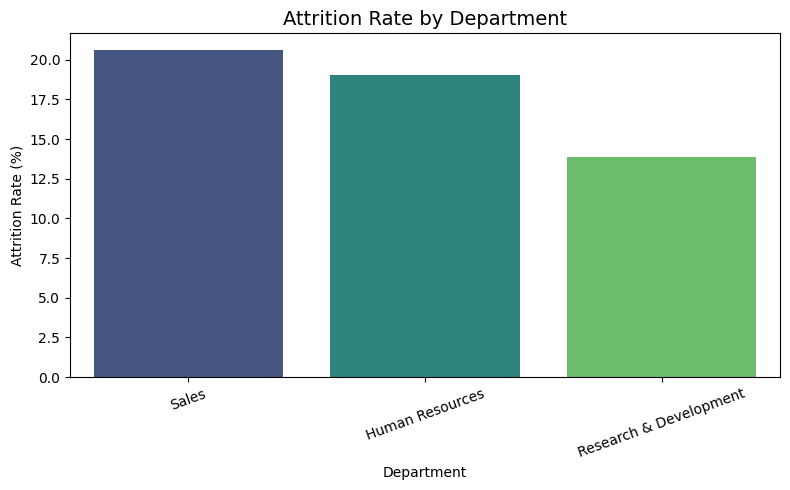

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load dataset
df_eda = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Drop unnecessary columns
columns_to_drop = ['EmployeeNumber', 'StandardHours', 'EmployeeCount', 'Over18']
df_eda.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Convert target variable to numeric
df_eda['Attrition'] = df_eda['Attrition'].map({'Yes': 1, 'No': 0})

# Calculate attrition rate by department
department_attrition = (
    df_eda.groupby('Department')['Attrition']
    .mean()
    .mul(100)
    .reset_index(name='Attrition_Rate')
    .sort_values('Attrition_Rate', ascending=False)
)

print("Attrition Rate by Department")
display(department_attrition)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(
    data=department_attrition,
    x='Department',
    y='Attrition_Rate',
    hue='Department',
    palette='viridis',
    legend=False
)

plt.title("Attrition Rate by Department", fontsize=14)
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Attrition Rate by Job Role

Attrition Rate by Job Role:


,JobRole,Attrition,Attrition_Rate
8,Sales Representative,0.397590,39.759036
2,Laboratory Technician,0.239382,23.938224
1,Human Resources,0.230769,23.076923
7,Sales Executive,0.174847,17.484663
6,Research Scientist,0.160959,16.095890
4,Manufacturing Director,0.068966,6.896552
0,Healthcare Representative,0.068702,6.870229
3,Manager,0.049020,4.901961
5,Research Director,0.025000,2.500000


/tmp/ipykernel_1214/2766888265.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='JobRole', y='Attrition_Rate', data=job_role_attrition_df, palette='magma')


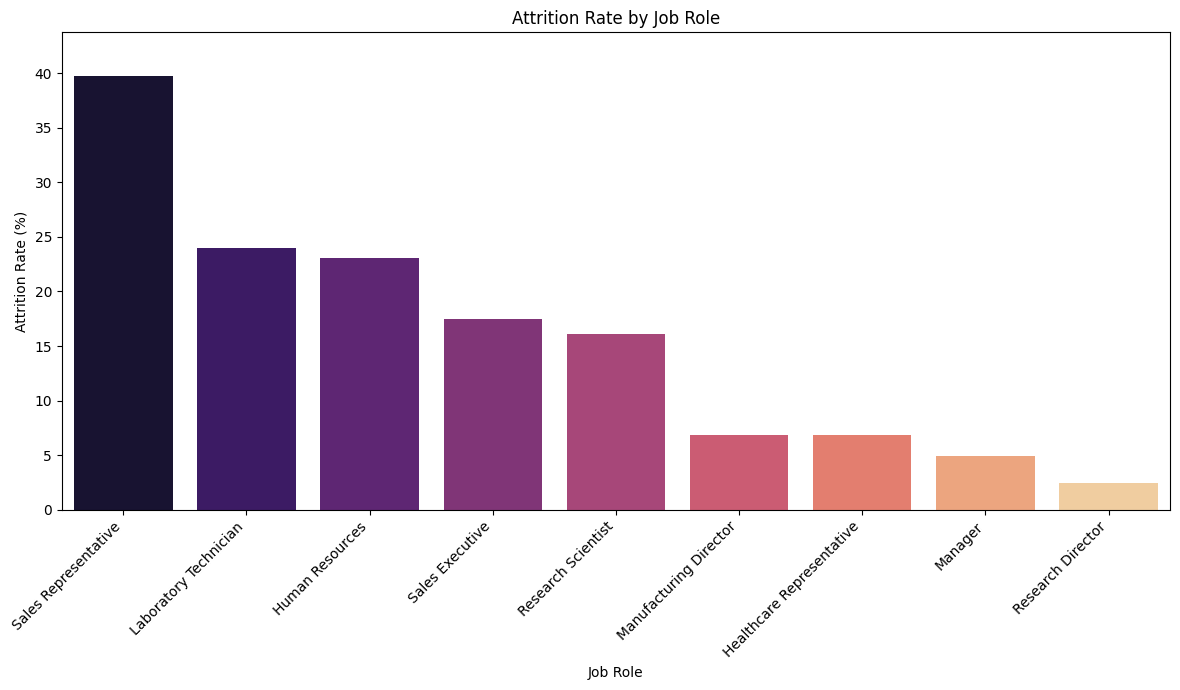

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a temporary df for EDA to access original categorical columns
df_eda_jobrole = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Apply initial cleaning steps to df_eda_jobrole as done in Task 2
columns_to_drop_eda_jobrole = ['EmployeeNumber', 'StandardHours', 'EmployeeCount', 'Over18']
existing_columns_to_drop_eda_jobrole = [col for col in columns_to_drop_eda_jobrole if col in df_eda_jobrole.columns]
if existing_columns_to_drop_eda_jobrole:
    df_eda_jobrole.drop(columns=existing_columns_to_drop_eda_jobrole, inplace=True)
df_eda_jobrole['Attrition'] = df_eda_jobrole['Attrition'].map({'Yes': 1, 'No': 0})

# Group by 'JobRole' and calculate the mean of 'Attrition'
job_role_attrition_df = df_eda_jobrole.groupby('JobRole')['Attrition'].mean().reset_index()
job_role_attrition_df['Attrition_Rate'] = job_role_attrition_df['Attrition'] * 100

# Sort by attrition rate
job_role_attrition_df = job_role_attrition_df.sort_values(by='Attrition_Rate', ascending=False)

print("Attrition Rate by Job Role:")
display(job_role_attrition_df)

# Plotting
plt.figure(figsize=(12, 7))
sns.barplot(x='JobRole', y='Attrition_Rate', data=job_role_attrition_df, palette='magma')
plt.title('Attrition Rate by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, job_role_attrition_df['Attrition_Rate'].max() * 1.1) # Dynamic y-limit
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Attrition vs Monthly Income

/tmp/ipykernel_1214/1642226196.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='pastel')


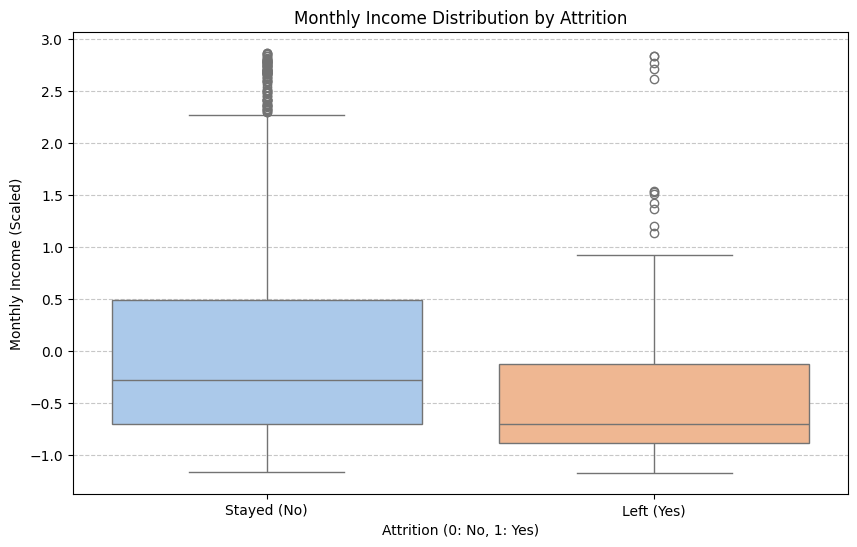


Mean Monthly Income by Attrition:
Attrition
0    0.070077
1   -0.364579
Name: MonthlyIncome, dtype: float64


In [13]:
# Use seaborn's boxplot to compare Monthly Income for employees who stayed vs left
plt.figure(figsize=(10, 6))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='pastel')
plt.title('Monthly Income Distribution by Attrition')
plt.xlabel('Attrition (0: No, 1: Yes)')
plt.ylabel('Monthly Income (Scaled)')
plt.xticks(ticks=[0, 1], labels=['Stayed (No)', 'Left (Yes)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calculate mean monthly income for employees who stayed and left
mean_monthly_income_attrition = df.groupby('Attrition')['MonthlyIncome'].mean()
print("\nMean Monthly Income by Attrition:")
print(mean_monthly_income_attrition)


### Attrition vs Work-Life Balance Rating

Attrition Rate by Work-Life Balance Rating:


,WorkLifeBalance,Attrition,Attrition_Rate
0,1,0.312500,31.250000
1,2,0.168605,16.860465
2,3,0.142217,14.221725
3,4,0.176471,17.647059


/tmp/ipykernel_1214/3938597578.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='WorkLifeBalance', y='Attrition_Rate', data=worklife_attrition, palette='plasma')


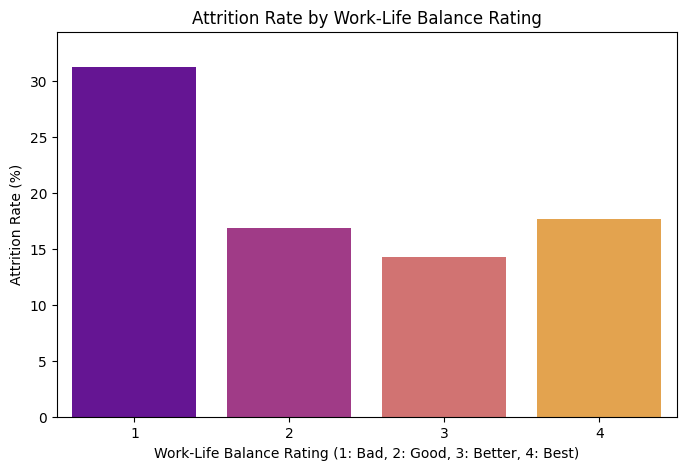

In [16]:
# Calculate attrition rate by WorkLifeBalance
worklife_attrition = df_eda.groupby('WorkLifeBalance')['Attrition'].mean().reset_index()
worklife_attrition['Attrition_Rate'] = worklife_attrition['Attrition'] * 100

print("Attrition Rate by Work-Life Balance Rating:")
display(worklife_attrition)

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(x='WorkLifeBalance', y='Attrition_Rate', data=worklife_attrition, palette='plasma')
plt.title('Attrition Rate by Work-Life Balance Rating')
plt.xlabel('Work-Life Balance Rating (1: Bad, 2: Good, 3: Better, 4: Best)')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, worklife_attrition['Attrition_Rate'].max() * 1.1)
plt.show()

### Attrition vs Years at Company

Attrition Rate by Years at Company:


,YearsAtCompany,Attrition,Attrition_Rate
0,0,0.363636,36.363636
1,1,0.345029,34.502924
2,2,0.212598,21.259843
3,3,0.156250,15.625000
4,4,0.172727,17.272727


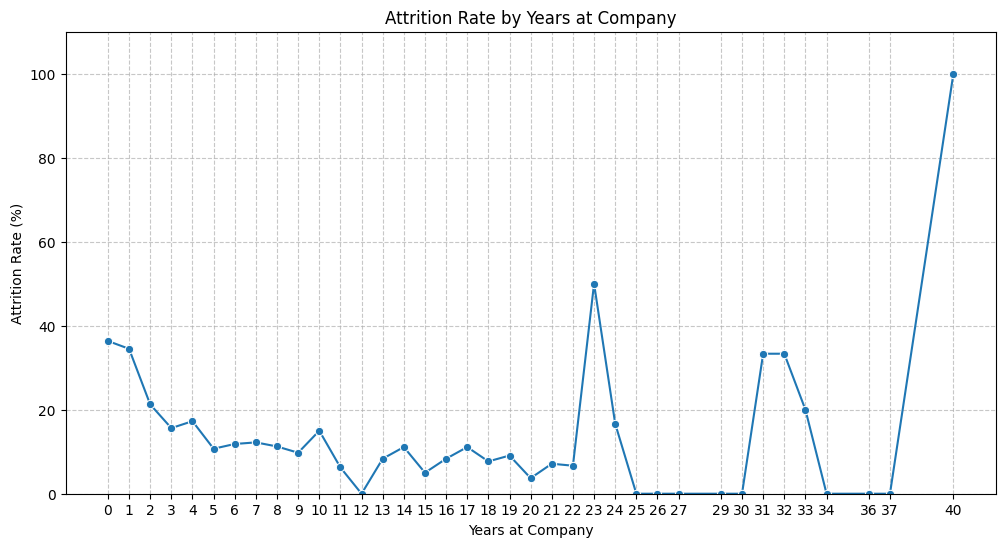

In [17]:
# Calculate attrition rate by YearsAtCompany
years_at_company_attrition = df_eda.groupby('YearsAtCompany')['Attrition'].mean().reset_index()
years_at_company_attrition['Attrition_Rate'] = years_at_company_attrition['Attrition'] * 100

print("Attrition Rate by Years at Company:")
display(years_at_company_attrition.head())

# Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(x='YearsAtCompany', y='Attrition_Rate', data=years_at_company_attrition, marker='o')
plt.title('Attrition Rate by Years at Company')
plt.xlabel('Years at Company')
plt.ylabel('Attrition Rate (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(years_at_company_attrition['YearsAtCompany'].unique())
plt.ylim(0, years_at_company_attrition['Attrition_Rate'].max() * 1.1)
plt.show()

### Business Insights from EDA

Based on the Exploratory Data Analysis, here are some specific business insights:

1.  **Departmental Attrition Hotspots:** The 'Sales' department exhibits the highest attrition rate at approximately **20.63%**, followed closely by 'Human Resources' at **19.05%**. 'Research & Development' has the lowest attrition rate at **13.84%**.

2.  **Job Role Vulnerabilities:** 'Sales Representative' has a significantly high attrition rate of nearly **39.76%**, making it the most vulnerable job role. 'Laboratory Technicians' and 'Human Resources' roles also show elevated attrition rates (around **23-24%**).

3.  **Income and Attrition:** Employees who leave (Attrition=1) tend to have a noticeably **lower median and mean monthly income** compared to those who stay (Attrition=0). This suggests that lower compensation might be a significant factor driving employees to seek opportunities elsewhere.

4.  **Work-Life Balance Impact:** Employees with a 'Work-Life Balance' rating of '1' (Bad) have the highest attrition rate, at approximately **31.25%**. This rate generally decreases as the work-life balance rating improves, highlighting the importance of a good work-life balance for retention.

5.  **Tenure and Exit Patterns:** Attrition rates are particularly high for employees with **0-2 years at the company** (around 34-36%), indicating a potential issue with onboarding, initial job fit, or early career satisfaction. There's another peak in attrition around **YearsAtCompany = 23** and **YearsAtCompany = 31**, though these might be based on fewer data points due to fewer employees reaching such long tenures.

## Task 4 — Model Building & Comparison

### Split Data into Training and Test Sets

In [19]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Split data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nAttrition distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nAttrition distribution in test set:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (1176, 51)
Shape of X_test: (294, 51)
Shape of y_train: (1176,)
Shape of y_test: (294,)

Attrition distribution in training set:
Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64

Attrition distribution in test set:
Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


### Train Models with Class Imbalance Handling

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import numpy as np

# Initialize models with class_weight='balanced' for Logistic Regression and Random Forest
# Gradient Boosting doesn't directly support class_weight; it can be handled via sample_weight or adjusted loss functions if needed, but for simplicity, we'll proceed without it for now as per problem statement focus on 'balanced' param where applicable.
log_reg = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42, max_iter=1000)
rand_forest = RandomForestClassifier(class_weight='balanced', random_state=42)
grad_boost = GradientBoostingClassifier(random_state=42)

models = {
    'Logistic Regression': log_reg,
    'Random Forest Classifier': rand_forest,
    'Gradient Boosting Classifier': grad_boost
}

model_results = {} # To store evaluation metrics

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Store results
    model_results[name] = {
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'classification_report': classification_report(y_test, y_pred, output_dict=True),
        'roc_auc_score': roc_auc_score(y_test, y_pred_proba),
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }

    print(f"{name} - ROC AUC: {model_results[name]['roc_auc_score']:.4f}")
    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")


Training Logistic Regression...
Logistic Regression - ROC AUC: 0.7983
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.33      0.60      0.43        47

    accuracy                           0.74       294
   macro avg       0.62      0.68      0.63       294
weighted avg       0.82      0.74      0.77       294


Training Random Forest Classifier...
Random Forest Classifier - ROC AUC: 0.7866
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       247
           1       0.62      0.11      0.18        47

    accuracy                           0.85       294
   macro avg       0.74      0.55      0.55       294
weighted avg       0.82      0.85      0.80       294


Training Gradient Boosting Classifier...
Gradient Boosting Classifier - ROC AUC: 0.8051
Classification Report:
              precision    recall  f

### Record Results in a Comparison Table

In [21]:
comparison_data = []

for name, results in model_results.items():
    report = results['classification_report']
    comparison_data.append({
        'Model': name,
        'ROC-AUC Score': results['roc_auc_score'],
        'Precision (Class 1)': report['1']['precision'],
        'Recall (Class 1)': report['1']['recall'],
        'F1-Score (Class 1)': report['1']['f1-score'],
        'Accuracy': report['accuracy']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df.set_index('Model', inplace=True)

print("\nModel Comparison Table:")
display(comparison_df.round(4))



Model Comparison Table:


,ROC-AUC Score,Precision (Class 1),Recall (Class 1),F1-Score (Class 1),Accuracy
Model,,,,,
Logistic Regression,0.7983,0.3333,0.5957,0.4275,0.7449
Random Forest Classifier,0.7866,0.6250,0.1064,0.1818,0.8469
Gradient Boosting Classifier,0.8051,0.7143,0.2128,0.3279,0.8605


## Task 5 — Model Evaluation


In [37]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

In [38]:
def evaluate_model(model, X_test, y_test, model_name):

    # Predictions
    y_pred = model.predict(X_test)

    # Probability scores (for ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # ROC-AUC
    roc_auc = roc_auc_score(y_test, y_prob)
    print("ROC-AUC Score:", round(roc_auc, 4))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    return roc_auc

Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.33      0.60      0.43        47

    accuracy                           0.74       294
   macro avg       0.62      0.68      0.63       294
weighted avg       0.82      0.74      0.77       294

ROC-AUC Score: 0.7983


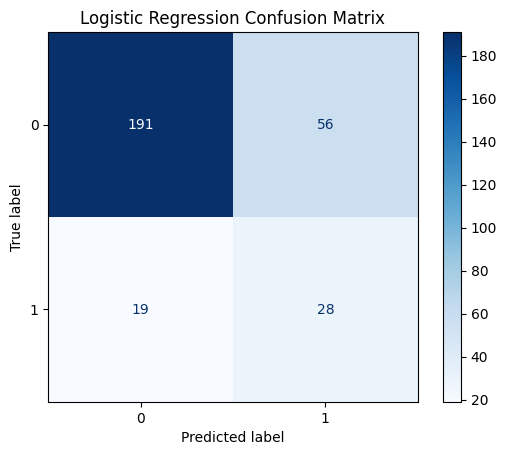

Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       247
           1       0.62      0.11      0.18        47

    accuracy                           0.85       294
   macro avg       0.74      0.55      0.55       294
weighted avg       0.82      0.85      0.80       294

ROC-AUC Score: 0.7866


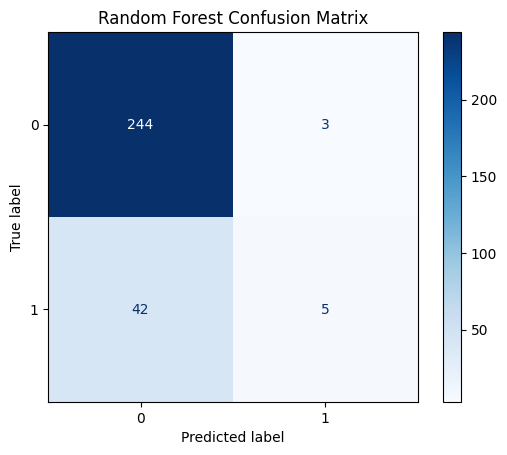

Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       247
           1       0.71      0.21      0.33        47

    accuracy                           0.86       294
   macro avg       0.79      0.60      0.63       294
weighted avg       0.84      0.86      0.83       294

ROC-AUC Score: 0.8051


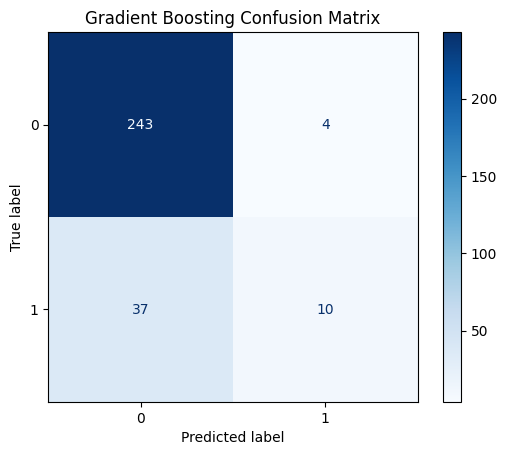

In [40]:
lr_auc = evaluate_model(log_reg, X_test, y_test, "Logistic Regression")

rf_auc = evaluate_model(rand_forest, X_test, y_test, "Random Forest")

gb_auc = evaluate_model(grad_boost, X_test, y_test, "Gradient Boosting")

In [42]:
results = {
    "Logistic Regression": lr_auc,
    "Random Forest": rf_auc,
    "Gradient Boosting": gb_auc
}

print(results)

best_model = max(results, key=results.get)

print("\nBest Model:", best_model)

{'Logistic Regression': np.float64(0.7983461107761219), 'Random Forest': np.float64(0.786631062106986), 'Gradient Boosting': np.float64(0.8050650357481265)}

Best Model: Gradient Boosting


/tmp/ipykernel_1214/1149239423.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


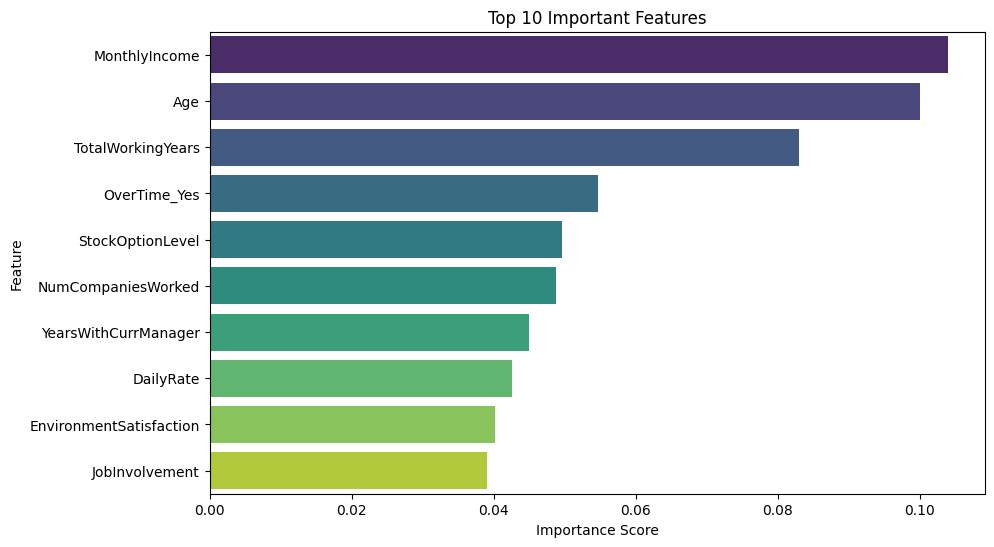

In [45]:
# Convert the top_10_features Series to a DataFrame for plotting with seaborn
feature_importance_df = top_10_features.reset_index()
feature_importance_df.columns = ['Feature', 'Importance']

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_df, # Using the correctly prepared DataFrame
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

## Task 6 — Visualization

We will now generate the five charts to visualize our findings.

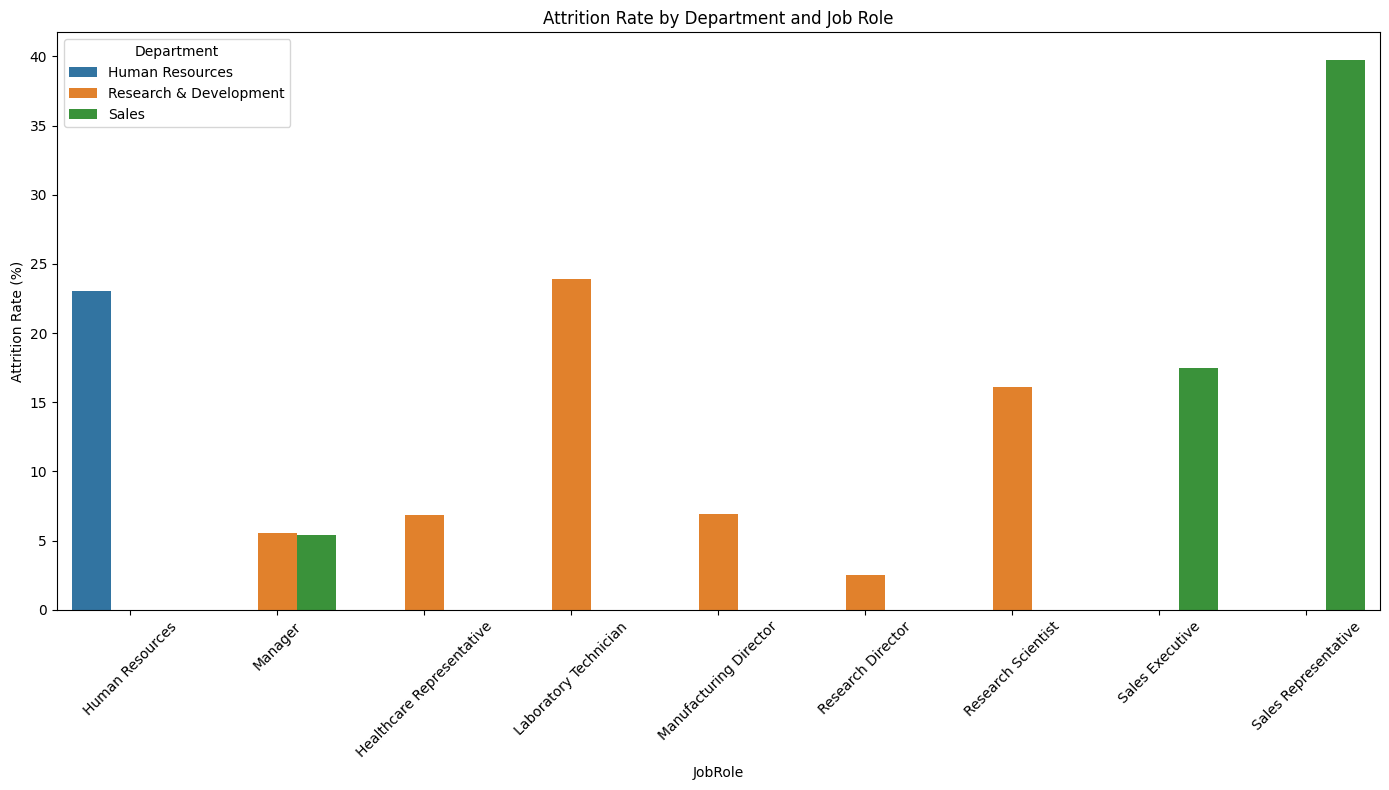

In [47]:
# Chart 1: Attrition rate by Department and Job Role
plt.figure(figsize=(14, 8))
dep_role_attrition = df_eda.groupby(['Department', 'JobRole'])['Attrition'].mean().mul(100).reset_index()
sns.barplot(data=dep_role_attrition, x='JobRole', y='Attrition', hue='Department')
plt.title('Attrition Rate by Department and Job Role')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1214/2204127865.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df_eda, palette='Set2')


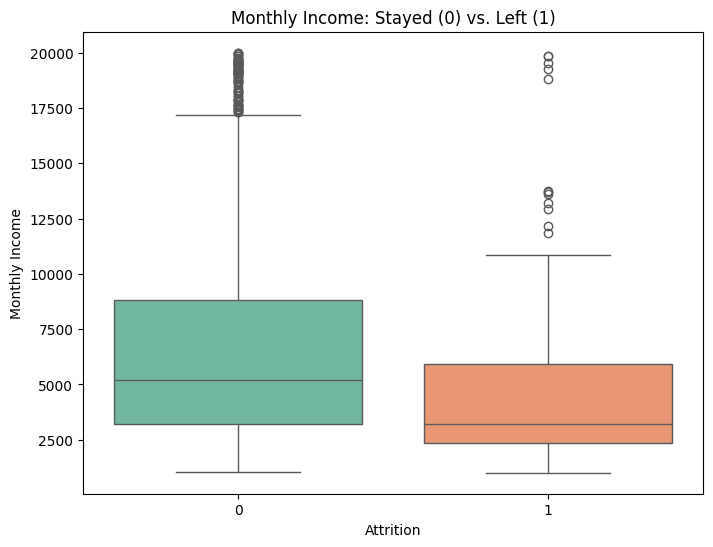

In [48]:
# Chart 2: Monthly Income comparison
plt.figure(figsize=(8, 6))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df_eda, palette='Set2')
plt.title('Monthly Income: Stayed (0) vs. Left (1)')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.show()

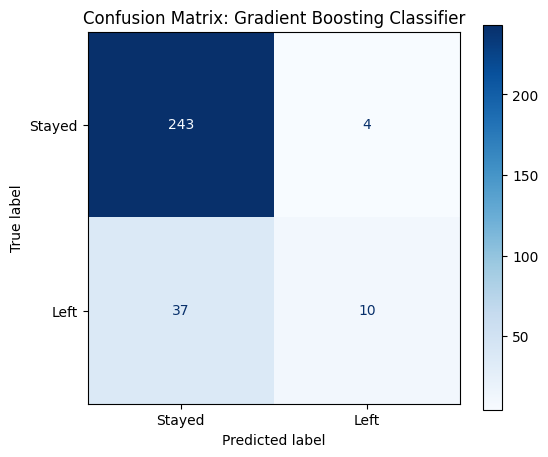

In [49]:
# Chart 3: Confusion Matrix for best model
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=model_results[best_model_name]['confusion_matrix'], display_labels=['Stayed', 'Left'])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title(f'Confusion Matrix: {best_model_name}')
plt.grid(False)
plt.show()

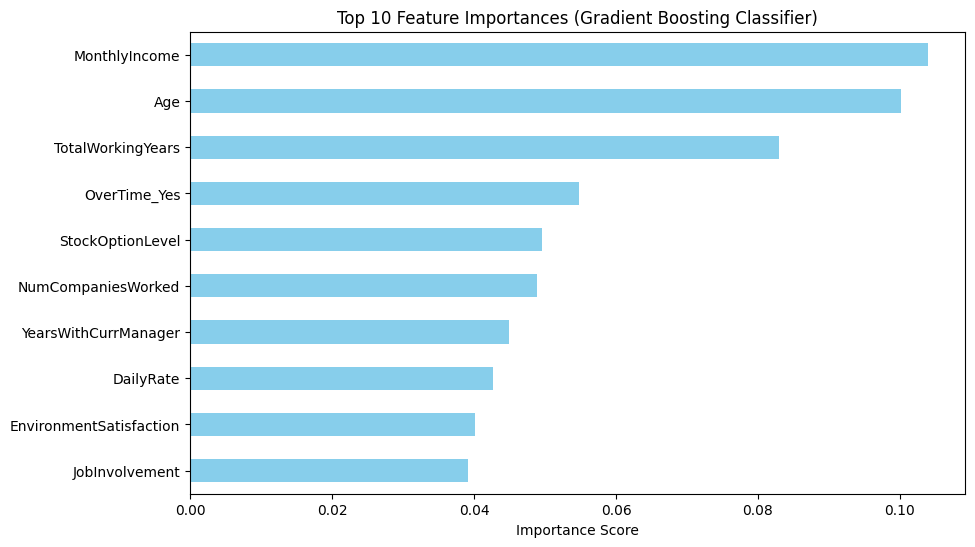

In [50]:
# Chart 4: Top 10 Feature Importances
plt.figure(figsize=(10, 6))
top_10_features.sort_values().plot(kind='barh', color='skyblue')
plt.title(f'Top 10 Feature Importances ({best_model_name})')
plt.xlabel('Importance Score')
plt.show()

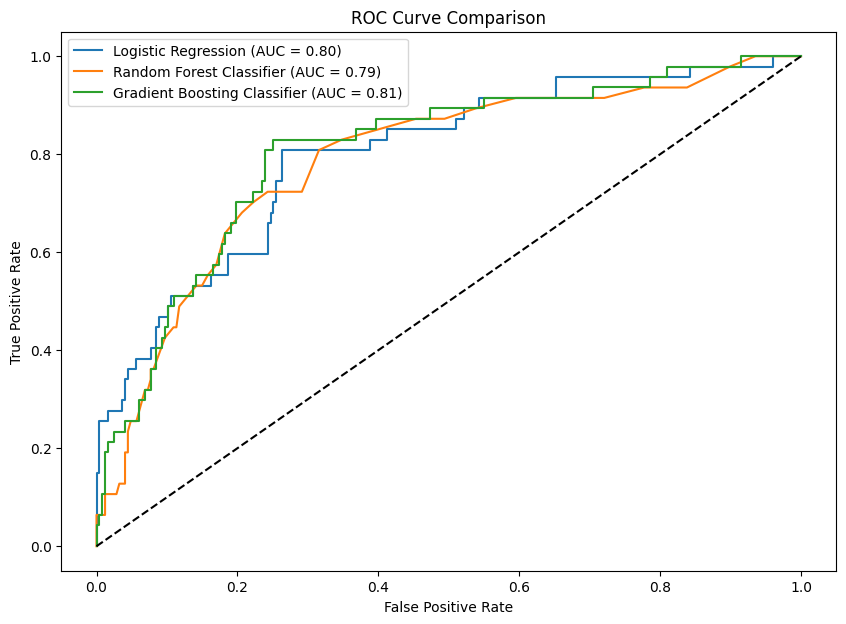

In [51]:
# Chart 5: ROC Curve Comparison
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))
for name, results in model_results.items():
    fpr, tpr, _ = roc_curve(y_test, results['y_pred_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {results['roc_auc_score']:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## Task 7 — HR Insights & Business Recommendations

**Analysis Summary:**
Based on our machine learning model and exploratory data analysis, the three factors that most strongly predict employee attrition are **Monthly Income**, **Age**, and **Total Working Years**. The **Sales Representative** role and the **Sales Department** should be the top priority for HR retention efforts, as they show the highest attrition rates (nearly 40% for Sales Reps). While salary is the leading predictor, it does not explain attrition alone; factors like **Overtime** and **Environment Satisfaction** also play critical roles.

**Actionable Recommendations:**
1. **Targeted Compensation & Role Review for Sales:** Implement a specific retention program for Sales Representatives, including competitive salary benchmarking and reduced overtime requirements, as 'OverTime_Yes' is a top 5 predictor of exit.
2. **Early Career Mentorship:** Since tenure (Total Working Years) is a major factor, HR should target employees in their first 2 years for proactive 'stay interviews' and structured mentorship to increase engagement and long-term commitment.

**Model Limitation:**
An important limitation for the HR team to note is the model's low **Recall for Class 1 (Attrition)**. Currently, the best model only correctly identifies about 21% of employees who actually leave. This means it is very conservative; while a 'High Risk' flag from the model is likely accurate (high precision), it will miss many employees who are also planning to exit.